[*********************100%***********************]  4 of 4 completed


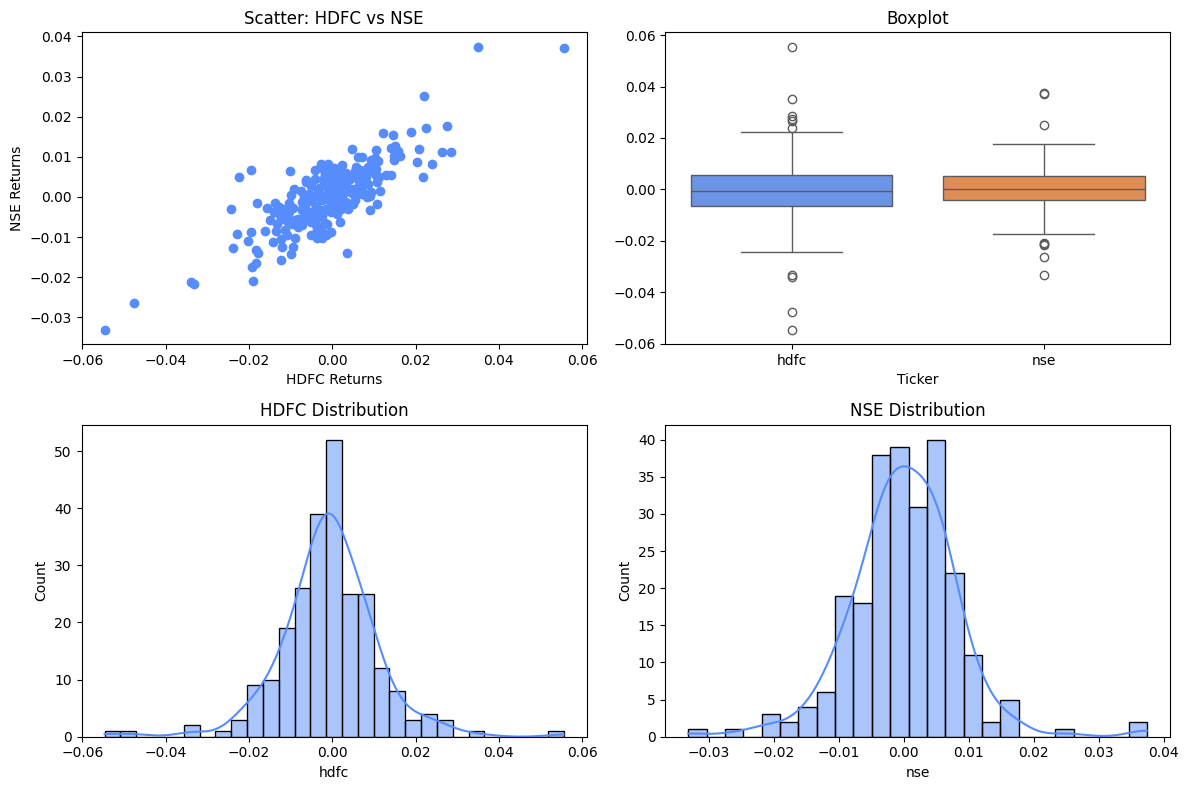

Intercept = -0.0008157556199653334
Slope = 1.146465986706218
R² = 0.6591990500010478
P-values = Intercept    6.560389e-02
nse          9.933835e-59
dtype: float64


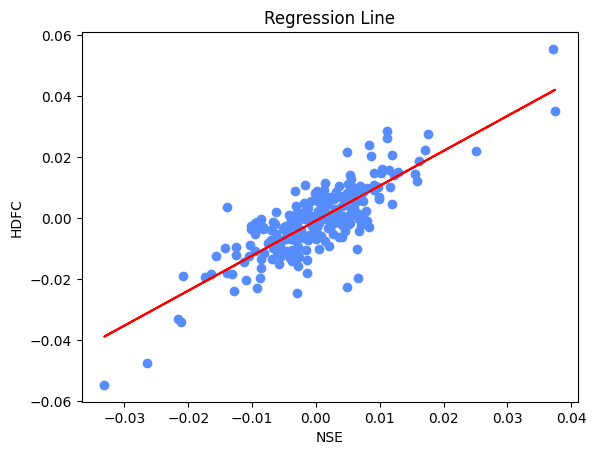

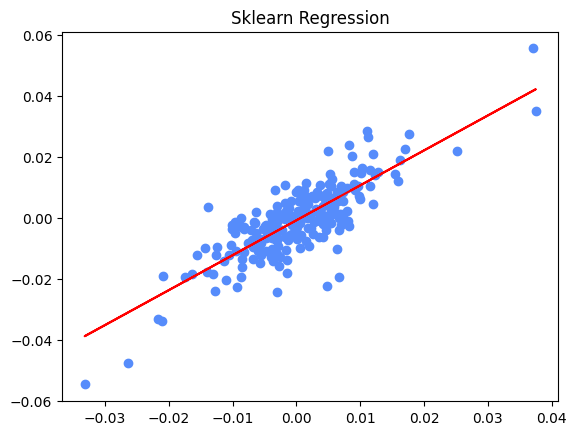

                            OLS Regression Results                            
Dep. Variable:                   hdfc   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.720
Method:                 Least Squares   F-statistic:                     315.4
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           3.86e-68
Time:                        16:40:30   Log-Likelihood:                 897.69
No. Observations:                 245   AIC:                            -1789.
Df Residuals:                     242   BIC:                            -1779.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0008      0.000     -2.085      0.0

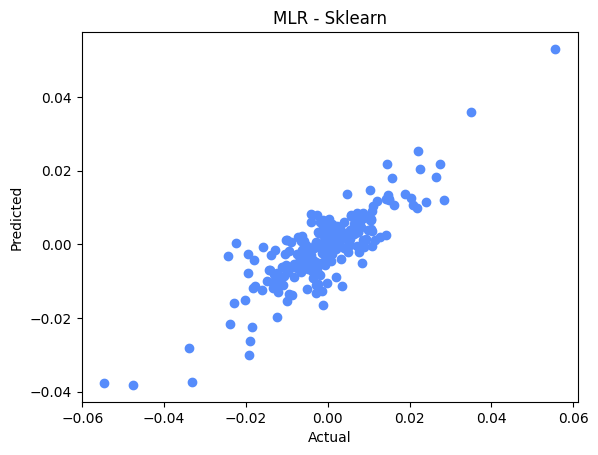

In [11]:
# -------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------

import numpy as np              # numerical operations
import pandas as pd             # data handling
import matplotlib.pyplot as plt # plotting
import seaborn as sns           # better visual plots
import datetime as dt           # working with dates
import yfinance as yf           # downloading market data
import statsmodels.formula.api as smf  # regression (formula style)
from sklearn.linear_model import LinearRegression  # ML regression


# -------------------------------
# 2. DOWNLOAD DATA
# -------------------------------

# Define time range (last 1 year)
end = dt.date.today()
start = end - dt.timedelta(days=365)

# Download price data for:
# HDFC Bank (stock)
# ICICI Bank (stock)
# NIFTY BANK (sector index)
# NIFTY 50 (market index)
df = yf.download(
    ['HDFCBANK.NS','ICICIBANK.NS','^NSEBANK', '^NSEI'],
    start=start,
    end=end,
    auto_adjust=True
)['Close']


# -------------------------------
# 3. CLEAN DATA
# -------------------------------

# Convert column names to lowercase (for consistency)
df.columns = df.columns.str.lower()

# Rename columns to simple names
df.rename(columns={
    'hdfcbank.ns':'hdfc',
    'icicibank.ns':'icici',
    '^nsebank':'nsebank',
    '^nsei':'nse'
}, inplace=True)


# -------------------------------
# 4. CALCULATE LOG RETURNS
# -------------------------------

# Copy original dataframe (so raw prices remain untouched)
returns = df.copy()

# Log return = ln(current price / previous price)
# Better than % returns for statistical modeling
returns['hdfc'] = np.log(df['hdfc'] / df['hdfc'].shift(1))
returns['icici'] = np.log(df['icici'] / df['icici'].shift(1))
returns['nsebank'] = np.log(df['nsebank'] / df['nsebank'].shift(1))
returns['nse'] = np.log(df['nse'] / df['nse'].shift(1))

# Remove NaN values created due to shifting
returns.dropna(inplace=True)


# -------------------------------
# 5. VISUAL ANALYSIS
# -------------------------------

plt.figure(figsize=(12,8))

# Scatter plot → relationship between variables
plt.subplot(2,2,1)
plt.scatter(returns['hdfc'], returns['nse'])
plt.xlabel('HDFC Returns')
plt.ylabel('NSE Returns')
plt.title('Scatter: HDFC vs NSE')

# Boxplot → detect outliers
plt.subplot(2,2,2)
sns.boxplot(data=returns[['hdfc','nse']])
plt.title('Boxplot')

# Distribution of HDFC returns
plt.subplot(2,2,3)
sns.histplot(returns['hdfc'], kde=True)
plt.title('HDFC Distribution')

# Distribution of NSE returns
plt.subplot(2,2,4)
sns.histplot(returns['nse'], kde=True)
plt.title('NSE Distribution')

plt.tight_layout()
plt.show()


# -------------------------------
# 6. SIMPLE REGRESSION
# -------------------------------

# Model: HDFC = alpha + beta * NSE
model = smf.ols('hdfc ~ nse', data=returns).fit()

# Alpha (intercept)
print("Intercept =", model.params['Intercept'])

# Beta (sensitivity to market)
print("Slope =", model.params['nse'])

# R-squared (how much movement is explained)
print("R² =", model.rsquared)

# P-values (statistical significance)
print("P-values =", model.pvalues)


# -------------------------------
# 7. REGRESSION LINE PLOT
# -------------------------------

plt.scatter(returns['nse'], returns['hdfc'])

# Plot predicted line: y = alpha + beta*x
plt.plot(
    returns['nse'],
    model.params['Intercept'] + model.params['nse'] * returns['nse'],
    color='red'
)

plt.xlabel('NSE')
plt.ylabel('HDFC')
plt.title('Regression Line')
plt.show()


# -------------------------------
# 8. SKLEARN VERSION (SAME MODEL)
# -------------------------------

# Independent variable (X)
x = returns[['nse']]

# Dependent variable (Y)
y = returns['hdfc']

# Train model
lr_model = LinearRegression()
lr_model.fit(x, y)

# Predictions
y_pred = lr_model.predict(x)

# Plot
plt.scatter(returns['nse'], returns['hdfc'])
plt.plot(returns['nse'], y_pred, color='red')
plt.title('Sklearn Regression')
plt.show()


# -------------------------------
# 9. MULTI-FACTOR REGRESSION
# -------------------------------

# Model: HDFC = alpha + beta1*NSE + beta2*NSEBANK
model = smf.ols('hdfc ~ nse + nsebank', data=returns).fit()

# Full summary
print(model.summary())

# Individual coefficients
print('Intercept =', model.params['Intercept'])
print('NSE beta =', model.params['nse'])
print('BankNifty beta =', model.params['nsebank'])

# Model performance
print('R² =', model.rsquared)
print('P-values =', model.pvalues)


# -------------------------------
# 10. SKLEARN MULTI-FACTOR
# -------------------------------

# Multiple inputs
x = returns[['nsebank','nse']]
y = returns['hdfc']

lr_model = LinearRegression()
lr_model.fit(x, y)

# Model parameters
print("Intercept:", lr_model.intercept_)
print("Coefficients:", lr_model.coef_)

# Predictions
y_pred = lr_model.predict(x)

# Plot actual vs predicted
plt.scatter(returns['hdfc'], y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('MLR - Sklearn')
plt.show()